# Token embeddings in 3D — `SetFusionNet`, MOXIFLOXACIN

`SetFusionNet` (`models/net.py`) is the only architecture here whose internal
representation is a **set of named tokens**: one `(B, d_model)` vector per
`(modality, locus)` feature block, produced by `SharedBlockEncoder` and then
tagged with a learned modality embedding + a learned locus embedding. Everything
downstream — the fusion transformer, the per-drug attention query — reads that
set. So "what has this model learned about a locus" is a question you can answer
by looking at where its token lands.

This notebook takes one trained model, pushes **every real isolate** through the
front half of `forward()`, and puts the resulting tokens in a shared 3D PCA space.

**Why this model.** `MOXIFLOXACIN` has exactly two coding loci (`gyrB`, `gyrA`),
and the `all_modalities` run carries four modalities, so each isolate produces
**8 tokens** — 2 loci × 4 modalities. Small enough that every group is legible
in one plot, big enough to show whether the model separates *locus* from
*modality*.

**Two stages are recorded**, because they answer different questions:

| stage | what it is | question it answers |
|---|---|---|
| `pre` | encoder output + modality/locus embeddings | do the blocks arrive distinguishable? |
| `post` | the same tokens after `model.fusion` | what does the transformer do to them? |

Each stage gets **its own PCA** — the two live at very different scales
(post-fusion norms are ~14× pre-fusion), so one shared basis would be entirely
`post` — and each is projected twice: raw, and with every `(modality, locus)`
group centered. Section 4 explains why the centered projection is the one you
want; the short version is that the genomes are nearly identical, so the raw
tokens are eight fixed points.

§6 writes a tidy CSV with one row per (isolate, token, stage); §7 animates it —
rotations of the pre- and post-fusion clouds, separately and side by side, plus a
flight between the two; §8 recolors all of it by phenotype and asks whether the
structure is worth anything, with a number rather than an eyeball.

> Run this with the **`abr_env`** kernel — it is the env the training jobs use
> (`scripts/sbatch/*.sh`), and the only one with `bigtb_ref`'s dependencies.

In [1]:
import json
import sys
import time
from pathlib import Path

PROJECT = Path("/home/jacksonmicha_umass_edu/abr_workspace/biophysical-fusion")
sys.path.insert(0, str(PROJECT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.decomposition import PCA

from datasets import load_dataset
from training.checkpoint import load_model, run_weights_dir

# --- what to inspect --------------------------------------------------------
RUN = "full_run_v2/all_modalities__setfusion"
STEM = "MOXIFLOXACIN__dna+protein+biophysical+regulatory"

# False = the 2,868 phenotyped isolates the model was actually fit and scored on
# (the rows in the checkpoint's isolates.txt). True adds the 15,074 isolates with
# no MOXIFLOXACIN phenotype — they have genotypes, so the model still encodes
# them, it just never saw a label for them. ~6x the forward passes.
ALL_ISOLATES = False

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH = 256
OUT_DIR = PROJECT / "results" / "figures" / "token_pca"
OUT_DIR.mkdir(parents=True, exist_ok=True)

torch.set_grad_enabled(False)
print(f"device={DEVICE}  out={OUT_DIR}")

device=cpu  out=/home/jacksonmicha_umass_edu/abr_workspace/biophysical-fusion/results/figures/token_pca


## 1. The trained model

`load_model` rebuilds the architecture from `config.json` and loads the weights of
the fold whose TEST metrics were reported. `block_keys` is the contract: token *i*
is that `(modality, locus)`, and `forward(xs)` expects the blocks in that order.

In [2]:
model, cfg = load_model(RUN, STEM, map_location=DEVICE)
model.to(DEVICE).eval()

D_MODEL = model.locus_emb.embedding_dim
LOCI = list(dict.fromkeys(locus for _, locus in model.block_keys))

print(f"{cfg['model']['arch']}  {cfg['drug']}  fold {cfg['best_fold']}  "
      f"{cfg['model']['n_params']:,} params  d_model={D_MODEL}")
print(f"loci       : {LOCI}")
print(f"modalities : {model.modalities}  (one shared encoder each)")
print(f"trained    : {cfg['data']['n_valid']:,} phenotyped of "
      f"{cfg['data']['n_isolates']:,} isolates "
      f"(R={cfg['data']['n_resistant']}, S={cfg['data']['n_susceptible']})")
print("\ntokens forward(xs) expects, in order:")
for i, (modality, locus) in enumerate(model.block_keys):
    channels, length = cfg["model"]["branch_specs"][i]
    print(f"  {i}  {modality:12s} {locus:5s}  ({channels:2d}, {length})")

setfusion  MOXIFLOXACIN  fold 0  733,505 params  d_model=128
loci       : ['gyrB', 'gyrA']
modalities : ['dna', 'protein', 'biophysical', 'regulatory']  (one shared encoder each)
trained    : 2,868 phenotyped of 17,942 isolates (R=388, S=2480)

tokens forward(xs) expects, in order:
  0  dna          gyrB   ( 5, 2134)
  1  dna          gyrA   ( 5, 2620)
  2  protein      gyrB   (20, 676)
  3  protein      gyrA   (20, 839)
  4  biophysical  gyrB   ( 3, 676)
  5  biophysical  gyrA   ( 3, 839)
  6  regulatory   gyrB   ( 5, 180)
  7  regulatory   gyrA   ( 5, 95)


/home/jacksonmicha_umass_edu/.conda/envs/abr_env/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


## 2. Rebuild the exact inputs

Every loader switch comes out of `config.json`'s `data` block, so the blocks are
the ones these weights were fit on. The asserts are the point of the cell — if
block order or shape drifted, token *i* would silently stop being the locus the
config claims, and the whole plot would be mislabelled.

In [3]:
d = cfg["data"]
t0 = time.time()
data = load_dataset(
    cfg["drug"], d["modalities_requested"], d["genotype_dir"], d["phenotype_csv"],
    regulatory_dir=d["regulatory_dir"],
    loci=d["loci_override"], regulatory_loci=d["regulatory_loci_override"],
    per_modality_branch=d["per_modality_branch"],
    extra_loci=d["extra_loci"], all_regulatory=d["all_regulatory"],
)
print(f"loaded {data.n:,} isolates in {time.time() - t0:.0f}s")

# --- the contract, checked -------------------------------------------------
assert [b.name for b in data.blocks] == [b["name"] for b in cfg["model"]["blocks"]], \
    "block ORDER differs from the checkpoint — token i would be the wrong locus"
assert data.branch_specs() == [tuple(s) for s in cfg["model"]["branch_specs"]], \
    "block shapes differ from the checkpoint"

fit_ids = (run_weights_dir(RUN, STEM) / "isolates.txt").read_text().split()
phenotyped = np.flatnonzero(data.y != -1)
assert [data.isolate_ids[i] for i in phenotyped] == fit_ids, \
    "the phenotyped rows are not the rows the model was fit on"

rows = np.arange(data.n) if ALL_ISOLATES else phenotyped
test_ids = set(cfg["split"]["test_isolate_ids"])
meta = pd.DataFrame({"isolate": [data.isolate_ids[i] for i in rows], "y": data.y[rows]})
meta["phenotype"] = meta.y.map({0: "resistant", 1: "susceptible", -1: "unphenotyped"})
meta["split"] = np.where(meta.isolate.isin(test_ids), "test", "train/cv")

print(f"\n{len(rows):,} isolates x {len(data.blocks)} tokens = "
      f"{len(rows) * len(data.blocks):,} points")
print(meta.phenotype.value_counts().to_string())
print(meta.split.value_counts().to_string())

loaded 17,942 isolates in 47s

2,868 isolates x 8 tokens = 22,944 points
phenotype
susceptible    2480
resistant       388
split
train/cv    2294
test         574


## 3. Pull the tokens out

This re-runs the first half of `SetFusionNet.forward` verbatim (`models/net.py`,
`forward`) and keeps the intermediates instead of the logits:

```
tokens = stack(encoders[modality_i](x_i))      +  modality_emb  +  locus_emb   # 'pre'
z      = fusion(tokens)                                                        # 'post'
```

Batched, because the DNA blocks are `(5, 2620)` per isolate and the full stack of
arrays is already several GB in RAM.

In [4]:
def token_stages(model, arrays, rows, batch=BATCH, device=DEVICE):
    '''Tokens before and after the fusion transformer.

    Returns two ``(len(rows), n_blocks, d_model)`` arrays:
      pre  — SharedBlockEncoder output + modality/locus embeddings; each block
             encoded in isolation, nothing has seen anything else yet.
      post — the same tokens after ``model.fusion``, i.e. contextualized by the
             other loci and modalities of the same isolate.
    '''
    ids = model._default_ids                      # (n_blocks, 2) embedding rows
    names = [model.modalities[i] for i in ids[:, 0].tolist()]
    pre, post = [], []
    for start in range(0, len(rows), batch):
        idx = rows[start:start + batch]
        xs = [torch.from_numpy(a[idx]).float().to(device) for a in arrays]
        tok = torch.stack([model.encoders[m](x) for m, x in zip(names, xs)], dim=1)
        tok = tok + model.modality_emb(ids[:, 0]) + model.locus_emb(ids[:, 1])
        pre.append(tok.cpu().numpy())
        post.append(model.fusion(tok).cpu().numpy())
    return np.concatenate(pre), np.concatenate(post)


t0 = time.time()
pre, post = token_stages(model, data.arrays(), rows)
print(f"pre  {pre.shape}   mean |token| = {np.linalg.norm(pre, axis=-1).mean():.2f}")
print(f"post {post.shape}   mean |token| = {np.linalg.norm(post, axis=-1).mean():.2f}")
print(f"{time.time() - t0:.0f}s")

pre  (2868, 8, 128)   mean |token| = 0.76
post (2868, 8, 128)   mean |token| = 10.92
20s


## 4. 3D PCA

One PCA per stage, fit on **all tokens of that stage at once** — that shared basis
is what makes the groups comparable: a `dna:gyrA` token and a `protein:gyrA` token
are projected onto the same three axes, so distance in the plot means something.

**But first, the fact that decides how to plot this.** *M. tuberculosis* is
effectively clonal: two isolates differ at a handful of positions in a 2.6 kb
gene. Run the ratio below and the token cloud for one `(modality, locus)` group
turns out to be ~10⁻³ of the distance *between* groups — the tokens are
essentially eight fixed points, with the isolate riding as a tiny perturbation
on top. A single PCA over the raw tokens therefore spends all three components
separating block identities and shows eight dots.

So each stage is projected **twice**:

| stage key | space | what you see |
|---|---|---|
| `pre` / `post` | raw tokens | where the eight blocks sit relative to each other |
| `pre_centered` / `post_centered` | each group centered and scaled to unit RMS | how isolates vary *within* a block — the only place per-sample structure lives |

Both transforms are per `(modality, locus)` group and happen **before** the PCA.
Centering removes the block identity; the unit-RMS scaling is needed on top of it
because the groups' within-spreads differ by ~10× (`biophysical:gyrA` is the
loudest), and without it the centered PCA is just that one group's variance.
The price is that distances are no longer comparable *across* groups in the
centered space — it answers "how do isolates vary", not "which block varies most".
That second question is what the spread table above is for.

In [5]:
spread = {}
for stage, tok in (("pre", pre), ("post", post)):
    cent = tok.mean(axis=0)                                   # (n_tokens, d_model)
    within = np.linalg.norm(tok - cent, axis=-1).mean()
    between = np.linalg.norm(cent[:, None] - cent[None], axis=-1)
    between = between[np.triu_indices_from(between, 1)].mean()
    spread[stage] = (within, between)
    print(f"{stage:4s}  mean within-group spread {within:.4f}   "
          f"mean between-group distance {between:.3f}   "
          f"ratio {within / between:.2e}")

pre   mean within-group spread 0.0009   mean between-group distance 0.925   ratio 9.78e-04
post  mean within-group spread 0.0062   mean between-group distance 1.766   ratio 3.52e-03


In [6]:
def center_scale(tok):
    '''Per-(modality, locus) centering + unit-RMS scaling. See the cell above.'''
    c = tok - tok.mean(axis=0)                                    # (n_iso, n_tok, d)
    rms = np.sqrt((c ** 2).sum(axis=-1).mean(axis=0))             # (n_tok,)
    return c / rms[None, :, None]


frames = []
pcas = {}
n_iso, n_tok, _ = pre.shape

for stage, tok in (("pre", pre), ("post", post)):
    for key, mat in ((stage, tok), (f"{stage}_centered", center_scale(tok))):
        flat = mat.reshape(-1, mat.shape[-1])          # (n_isolates * n_tokens, d_model)
        pca = PCA(n_components=3, random_state=0).fit(flat)
        xyz = pca.transform(flat)
        pcas[key] = pca
        ev = pca.explained_variance_ratio_
        print(f"{key:14s}  PC1-3 = {ev.sum():5.1%} of token variance "
              f"({' / '.join(f'{v:.1%}' for v in ev)})")
        frames.append(pd.DataFrame({
            "stage": key,
            "isolate": np.repeat(meta.isolate.values, n_tok),
            "phenotype": np.repeat(meta.phenotype.values, n_tok),
            "split": np.repeat(meta.split.values, n_tok),
            "modality": np.tile([m for m, _ in model.block_keys], n_iso),
            "locus": np.tile([l for _, l in model.block_keys], n_iso),
            "pc1": xyz[:, 0], "pc2": xyz[:, 1], "pc3": xyz[:, 2],
        }))

tokens_df = pd.concat(frames, ignore_index=True)
tokens_df["group"] = tokens_df.modality + ":" + tokens_df.locus
tokens_df.head()

pre             PC1-3 = 94.0% of token variance (56.3% / 19.5% / 18.1%)


pre_centered    PC1-3 = 30.8% of token variance (11.5% / 11.1% / 8.1%)


post            PC1-3 = 94.1% of token variance (41.5% / 40.3% / 12.3%)
post_centered   PC1-3 = 66.8% of token variance (50.1% / 9.8% / 6.9%)


,stage,isolate,phenotype,split,modality,locus,pc1,pc2,pc3,group
0,pre,SAMEA1015922,susceptible,test,dna,gyrB,-0.337678,-0.435259,0.069801,dna:gyrB
1,pre,SAMEA1015922,susceptible,test,dna,gyrA,-0.310744,-0.471614,0.009328,dna:gyrA
2,pre,SAMEA1015922,susceptible,test,protein,gyrB,-0.204059,0.278573,0.415052,protein:gyrB
3,pre,SAMEA1015922,susceptible,test,protein,gyrA,-0.178025,0.241656,0.354621,protein:gyrA
4,pre,SAMEA1015922,susceptible,test,biophysical,gyrB,0.796938,-0.005749,-0.010427,biophysical:gyrB


## 5. Plot

**Encoding.** Modality is the hue; locus is the marker shape *and* a repeat of the
hue in the legend, so the two loci never rely on color alone. The four hues are
slots 1/5/6/7 of the house categorical palette — the four-hue subset that clears
the all-pairs colorblind gate a scatter needs (worst pair ΔE 13.0 protan, 16.3
normal-vision, both above the 8 / 15 floors). The legend carries visible text
labels, which is the required relief for the one hue below 3:1 against the surface.

**One marker per distinct position, area ∝ √(isolates there).** Drawing 22,944
tiny translucent dots was unreadable, and for a good reason: thousands of them are
*exactly* on top of each other, because thousands of isolates carry an identical
alignment at these loci. `aggregate()` collapses each group's identical positions
into one opaque marker and encodes the pile-up as size, so nothing is hidden and
every marker is visible. Markers carry a surface-colored ring, which keeps
overlapping ones separable.

`plot_tokens` takes `elev` / `azim`, so the animations in §7 are loops over
viewing angles with no other change.

The raw-token plot below is the eight-points-in-space result the spread ratio
predicted. The interesting picture is the centered one two cells down.

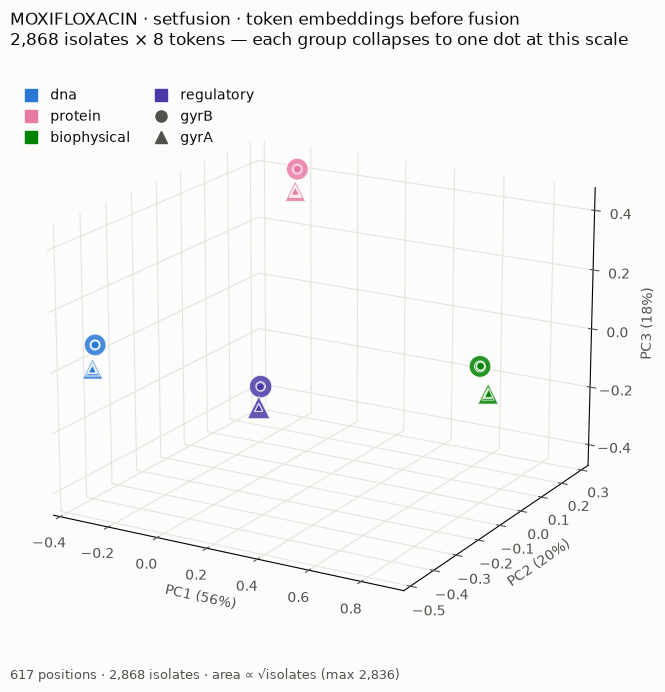

In [7]:
# house categorical palette — hues chosen for all-pairs CVD separation
MODALITY_COLOR = {"dna": "#2a78d6", "protein": "#e87ba4",
                  "biophysical": "#008300", "regulatory": "#4a3aa7"}
LOCUS_MARKER = dict(zip(LOCI, ["o", "^", "s", "D"]))
SURFACE, INK, MUTED, RULE = "#fcfcfb", "#0b0b0b", "#52514e", "#e5e4e0"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": MUTED, "grid.color": RULE,
    "xtick.color": MUTED, "ytick.color": MUTED, "font.size": 10,
    "axes.titlesize": 12, "legend.frameon": False,
})


def _style(ax, stage, pca):
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.set_pane_color(SURFACE)
    ev = pca.explained_variance_ratio_
    ax.set_xlabel(f"PC1 ({ev[0]:.0%})")
    ax.set_ylabel(f"PC2 ({ev[1]:.0%})")
    ax.set_zlabel(f"PC3 ({ev[2]:.0%})")


def view_box(sub, clip):
    '''Central `clip`% box per axis — heavy tails otherwise set the whole scale.'''
    lo, hi = (100 - clip) / 2, 100 - (100 - clip) / 2
    return [tuple(np.percentile(sub[c], [lo, hi])) for c in ("pc1", "pc2", "pc3")]


SMIN, SMAX = 26, 260          # marker area in pt^2, floor and ceiling


def add_legend(ax, modalities):
    '''Hue = modality, marker = locus. Identity is never carried by color alone.'''
    handles = ([plt.Line2D([], [], ls="", marker="s", ms=8, color=c, label=m)
                for m, c in MODALITY_COLOR.items() if m in modalities]
               + [plt.Line2D([], [], ls="", marker=LOCUS_MARKER[l], ms=8,
                             color=MUTED, label=l) for l in LOCI])
    ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(0.0, 0.95),
              labelcolor=INK, handletextpad=0.4, ncols=2, columnspacing=1.2,
              borderpad=0)


def aggregate(df, stage, decimals=5):
    '''One row per distinct token position within a group, with an isolate count.'''
    sub = df[df.stage == stage].copy()
    for c in ("pc1", "pc2", "pc3"):
        sub[f"k_{c}"] = sub[c].round(decimals)
    out = (sub.groupby(["modality", "locus", "k_pc1", "k_pc2", "k_pc3"],
                       as_index=False)
              .agg(n=("isolate", "size")))
    return out.rename(columns={"k_pc1": "pc1", "k_pc2": "pc2", "k_pc3": "pc3"})


def marker_size(n, n_max):
    '''Area proportional to sqrt(count): a 1,000x pile-up must not make the
    singletons invisible, which straight area-proportional sizing would do.'''
    return SMIN + (SMAX - SMIN) * np.sqrt(n / max(n_max, 1))


def plot_tokens(df, stage="pre", ax=None, elev=18, azim=-60, alpha=0.85,
                groups=None, legend=True, clip=None, scale=1.0, ring=0.6):
    '''3D PCA scatter of one stage's tokens. One call per view angle.'''
    pts = aggregate(df, stage)
    if groups is not None:
        pts = pts[(pts.modality + ":" + pts.locus).isin(groups)]
    n_iso = int(pts.n.sum() / len(model.block_keys))
    box = None
    if clip is not None:
        box = view_box(df[df.stage == stage], clip)
        keep = np.ones(len(pts), bool)
        for c, (lo, hi) in zip(("pc1", "pc2", "pc3"), box):
            keep &= pts[c].between(lo, hi).values
        print(f"{stage}: view clipped to the central {clip}% per axis — "
              f"{pts.n[~keep].sum():,} of {pts.n.sum():,} tokens "
              f"({pts.n[~keep].sum() / pts.n.sum():.1%}) fall outside "
              f"and are not drawn")
        pts = pts[keep]
    if ax is None:
        fig = plt.figure(figsize=(9.5, 8))
        ax = fig.add_subplot(projection="3d")
    n_max = pts.n.max()
    for (modality, locus), g in pts.groupby(["modality", "locus"], sort=False):
        ax.scatter(g.pc1, g.pc2, g.pc3, s=marker_size(g.n.values, n_max) * scale,
                   alpha=alpha, color=MODALITY_COLOR[modality],
                   marker=LOCUS_MARKER[locus], linewidths=ring, edgecolors=SURFACE,
                   depthshade=False)
    if box is not None:
        ax.set_xlim(*box[0]); ax.set_ylim(*box[1]); ax.set_zlim(*box[2])
    ax.view_init(elev=elev, azim=azim)
    _style(ax, stage, pcas[stage])
    if legend:
        add_legend(ax, set(pts.modality))
    ax.text2D(0.0, -0.02, f"{len(pts):,} positions · {n_iso:,} isolates · "
              f"area ∝ √isolates (max {n_max:,})", transform=ax.transAxes,
              color=MUTED, fontsize=9)
    return ax


ax = plot_tokens(tokens_df, "pre")
ax.set_title(f"{cfg['drug']} · setfusion · token embeddings before fusion\n"
             f"{len(rows):,} isolates × {len(model.block_keys)} tokens — "
             f"each group collapses to one dot at this scale",
             color=INK, loc="left", pad=0)
plt.savefig(OUT_DIR / f"tokens_pre_{cfg['drug']}.png", dpi=160, bbox_inches="tight")
plt.show()

Same isolates, same code path, one transformer later. The fusion stack pushes the
eight tokens roughly twice as far apart (that is the `between` column of the
spread table) — but the picture is still eight dots, because it moves the *groups*,
not the isolates within them.

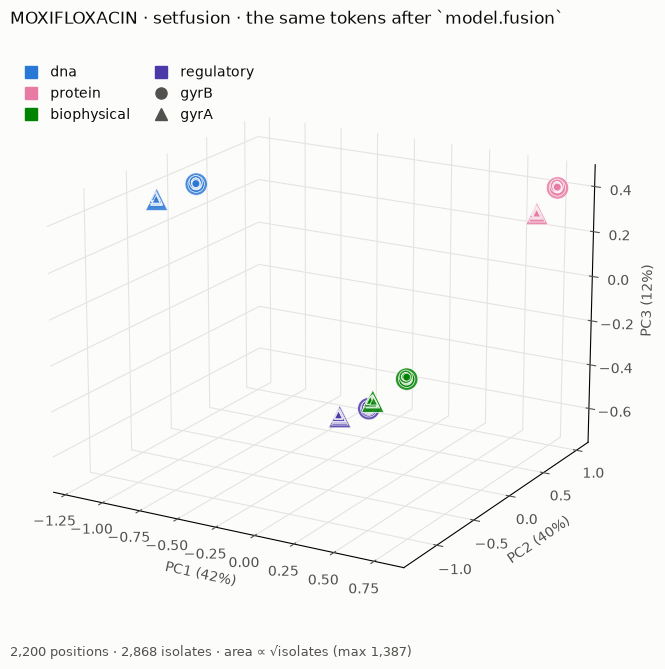

In [8]:
ax = plot_tokens(tokens_df, "post")
ax.set_title(f"{cfg['drug']} · setfusion · the same tokens after `model.fusion`",
             color=INK, loc="left", pad=0)
plt.savefig(OUT_DIR / f"tokens_post_{cfg['drug']}.png", dpi=160, bbox_inches="tight")
plt.show()

### The centered space — where the isolates actually are

Center and rescale each `(modality, locus)` group and every one of the 2,868
isolates becomes visible. Same encoding, three orders of magnitude smaller axes.
**This** is the view worth animating: one point per isolate per token, and the
point moves when the genotype does.

The view is clipped to the central 95% per axis — a handful of isolates sit far
out and would otherwise set the scale for everything. The cell prints how many
points that hides; it is never a silent truncation. Pass `clip=None` for the
full range.

pre_centered: view clipped to the central 95% per axis — 2,131 of 22,944 tokens (9.3%) fall outside and are not drawn


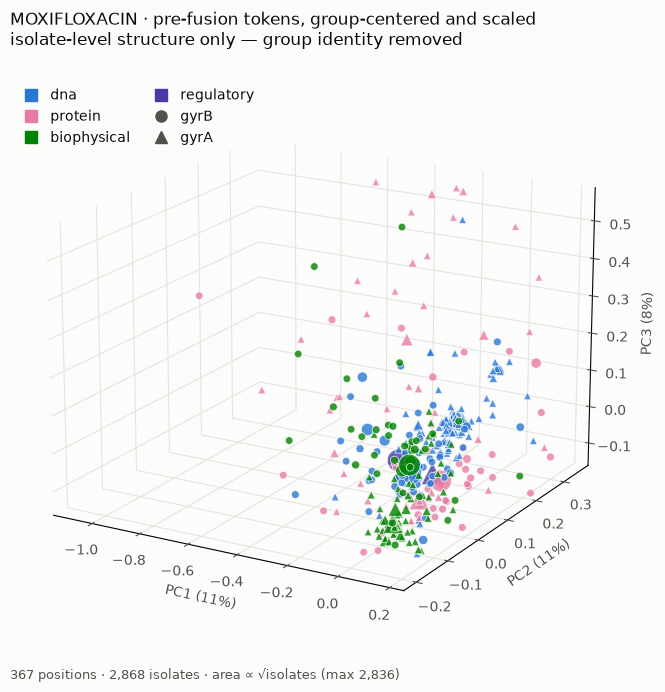

In [9]:
ax = plot_tokens(tokens_df, "pre_centered", clip=95, alpha=0.8)
ax.set_title(f"{cfg['drug']} · pre-fusion tokens, group-centered and scaled\n"
             f"isolate-level structure only — group identity removed",
             color=INK, loc="left", pad=0)
plt.savefig(OUT_DIR / f"tokens_pre_centered_{cfg['drug']}.png", dpi=160,
            bbox_inches="tight")
plt.show()

### Small multiples

The centered plot overplots — eight clouds of 2,868 points sharing one origin.
Same axes, one panel per `(modality, locus)`, is the honest read of which blocks
carry isolate-to-isolate variation at all and which are nearly constant.

/tmp/ipykernel_1161277/1385112058.py:42: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.savefig(OUT_DIR / f"tokens_pre_centered_facets_{cfg['drug']}.png", dpi=160)


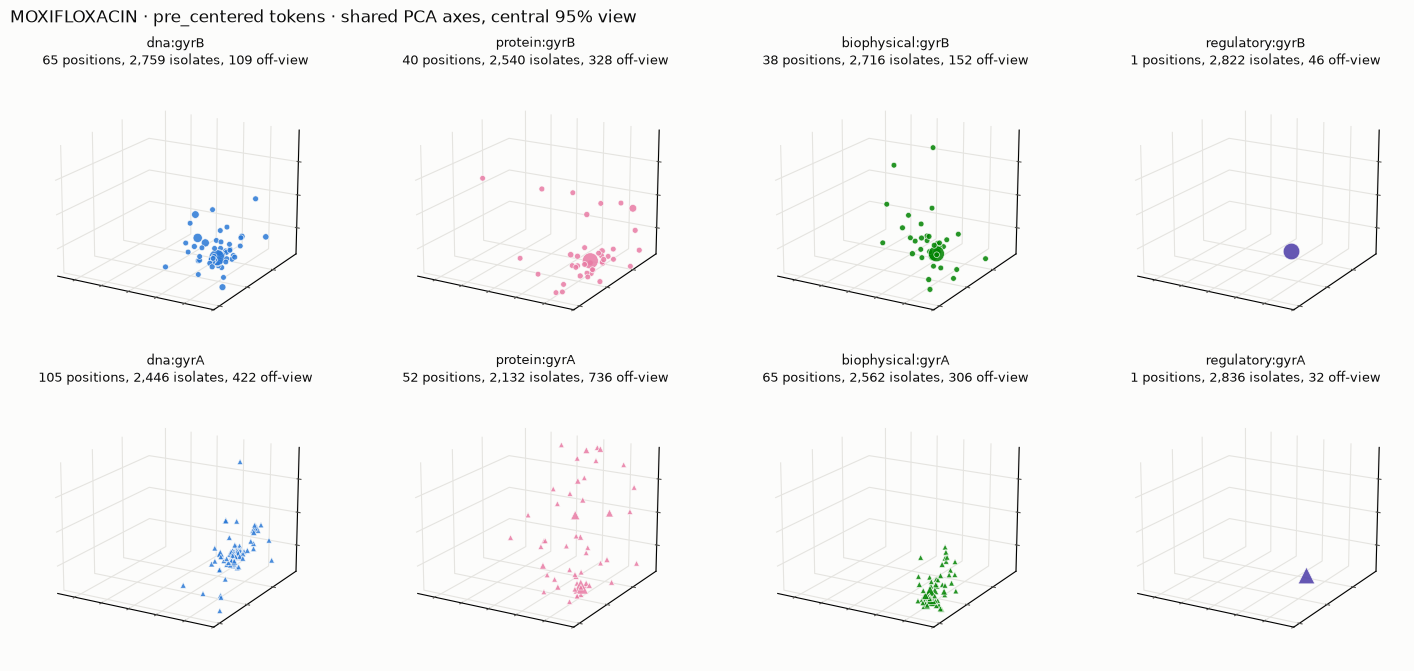

In [10]:
def small_multiples(df, stage="pre_centered", elev=18, azim=-60, alpha=0.85,
                    clip=95, scale=0.55):
    sub = aggregate(df, stage)
    lims = (view_box(df[df.stage == stage], clip) if clip is not None
            else [(sub[c].min(), sub[c].max()) for c in ("pc1", "pc2", "pc3")])
    n_max = sub.n.max()
    modalities = [m for m in MODALITY_COLOR if m in set(sub.modality)]
    fig, axes = plt.subplots(len(LOCI), len(modalities),
                             figsize=(3.6 * len(modalities), 3.3 * len(LOCI)),
                             subplot_kw={"projection": "3d"}, layout="constrained")
    axes = np.atleast_2d(axes)
    for r, locus in enumerate(LOCI):
        for c, modality in enumerate(modalities):
            ax = axes[r, c]
            g = sub[(sub.locus == locus) & (sub.modality == modality)]
            inside = np.ones(len(g), bool)
            for col, (lo, hi) in zip(("pc1", "pc2", "pc3"), lims):
                inside &= g[col].between(lo, hi).values
            drawn = g[inside]
            ax.scatter(drawn.pc1, drawn.pc2, drawn.pc3,
                       s=marker_size(drawn.n.values, n_max) * scale, alpha=alpha,
                       color=MODALITY_COLOR[modality], marker=LOCUS_MARKER[locus],
                       linewidths=0.5, edgecolors=SURFACE, depthshade=False)
            ax.set_xlim(*lims[0]); ax.set_ylim(*lims[1]); ax.set_zlim(*lims[2])
            ax.view_init(elev=elev, azim=azim)
            for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
                axis.set_pane_color(SURFACE)
            ax.set_xticklabels([]); ax.set_yticklabels([]); ax.set_zticklabels([])
            off = int(g.n.sum() - drawn.n.sum())
            ax.set_title(f"{modality}:{locus}\n{len(drawn):,} positions, "
                         f"{int(drawn.n.sum()):,} isolates"
                         + (f", {off} off-view" if off else ""),
                         color=INK, fontsize=9.5, pad=-8, linespacing=1.3)
    fig.suptitle(f"{cfg['drug']} · {stage} tokens · shared PCA axes, "
                 f"central {clip}% view" if clip else
                 f"{cfg['drug']} · {stage} tokens · shared PCA axes",
                 color=INK, x=0.01, ha="left", fontsize=12)
    return fig


fig = small_multiples(tokens_df, "pre_centered")
fig.savefig(OUT_DIR / f"tokens_pre_centered_facets_{cfg['drug']}.png", dpi=160)
plt.show()

### How separated are the groups, numerically?

The plot shows three of `d_model` = 128 dimensions. Group centroid distances in
the **full** space say whether what you see is the whole story.

In [11]:
for stage, tok in (("pre", pre), ("post", post)):
    flat = tok.reshape(-1, tok.shape[-1])
    groups = np.tile([f"{m}:{l}" for m, l in model.block_keys], tok.shape[0])
    cent = pd.DataFrame(flat).groupby(groups, sort=False).mean()
    within = pd.Series(
        {g: np.linalg.norm(flat[groups == g] - cent.loc[g].values, axis=1).mean()
         for g in cent.index})
    d = pd.DataFrame(
        np.linalg.norm(cent.values[:, None] - cent.values[None], axis=-1),
        index=cent.index, columns=cent.index)
    print(f"\n=== {stage} ===  mean within-group spread {within.mean():.5f}, "
          f"mean centroid distance {d.values[np.triu_indices_from(d, 1)].mean():.3f}")
    print("centroid distances (full 128-d space):")
    print(d.round(2).to_string())


=== pre ===  mean within-group spread 0.00090, mean centroid distance 0.925
centroid distances (full 128-d space):
                  dna:gyrB  dna:gyrA  protein:gyrB  protein:gyrA  biophysical:gyrB  biophysical:gyrA  regulatory:gyrB  regulatory:gyrA
dna:gyrB              0.00      0.32          0.81          0.83              1.22              1.31             0.80             0.86
dna:gyrA              0.32      0.00          0.90          0.81              1.24              1.26             0.86             0.80
protein:gyrB          0.81      0.90          0.00          0.32              1.13              1.25             0.79             0.88
protein:gyrA          0.83      0.81          0.32          0.00              1.13              1.17             0.81             0.78
biophysical:gyrB      1.22      1.24          1.13          1.13              0.00              0.34             1.21             1.23
biophysical:gyrA      1.31      1.26          1.25          1.17          

### How many *distinct* points are there?

The facets look far sparser than 2,868 markers. They are: the isolates are highly
redundant at these two loci, so many share a byte-identical alignment and land on
exactly the same token. Worth knowing before animating — an animation that steps
through 2,868 isolates may only ever show a few dozen positions.

Read the two columns differently. `pre` counts distinct sequences *of that one
block* — `regulatory:gyrA`'s 95 bp window takes a single-digit number of forms
across the whole cohort. `post` is identical for every group because fusion makes
each token a function of all eight, so its count is the number of distinct
**genotypes** in the block set as a whole.

In [12]:
distinct = pd.DataFrame({
    stage: {f"{m}:{l}": len(np.unique(np.round(tok[:, i], 5), axis=0))
            for i, (m, l) in enumerate(model.block_keys)}
    for stage, tok in (("pre", pre), ("post", post))
})
distinct.insert(0, "isolates", len(rows))
print("distinct token positions per group (rounded to 1e-5):")
print(distinct.to_string())

distinct token positions per group (rounded to 1e-5):
                  isolates  pre  post
dna:gyrB              2868   98   275
dna:gyrA              2868  163   275
protein:gyrB          2868   68   275
protein:gyrA          2868  112   275
biophysical:gyrB      2868   68   275
biophysical:gyrA      2868  112   275
regulatory:gyrB       2868   14   275
regulatory:gyrA       2868    8   275


## 6. Save the tidy table

One row per (isolate, token, stage) with its 3D position and its labels. This is
what the animation will read — no need to re-run the forward pass to build it.

In [13]:
csv = OUT_DIR / f"tokens_pca_{cfg['drug']}_{cfg['model']['arch']}.csv"
# 6 dp, not 4: the centered coordinates live at ~1e-2 and 4 dp would throw away
# most of their significant digits.
tokens_df.round(6).to_csv(csv, index=False)
print(f"{len(tokens_df):,} rows -> {csv}")
tokens_df.groupby(["stage", "group"], sort=False).size().rename("n").to_frame().T

91,776 rows -> /home/jacksonmicha_umass_edu/abr_workspace/biophysical-fusion/results/figures/token_pca/tokens_pca_MOXIFLOXACIN_setfusion.csv


stage      pre                                                      \
group dna:gyrB dna:gyrA protein:gyrB protein:gyrA biophysical:gyrB   
n         2868     2868         2868         2868             2868   

stage                                                  pre_centered           \
group biophysical:gyrA regulatory:gyrB regulatory:gyrA     dna:gyrB dna:gyrA   
n                 2868            2868            2868         2868     2868   

stage  ...            post                 post_centered           \
group  ... regulatory:gyrB regulatory:gyrA      dna:gyrB dna:gyrA   
n      ...            2868            2868          2868     2868   

stage                                                              \
group protein:gyrB protein:gyrA biophysical:gyrB biophysical:gyrA   
n             2868         2868             2868             2868   

stage                                  
group regulatory:gyrB regulatory:gyrA  
n                2868            2868  

[1 rows x 32 columns]

## 7. The animations

Four, all written as **GIFs** — this cluster has no `ffmpeg`, so matplotlib only
offers the pillow writer. All reuse `aggregate` / `marker_size`, so a marker is
a distinct token position sized by how many isolates sit on it, and both clip to
the central 95% per axis, the same as the static figures. Each cell prints how
many tokens that hides (~9%: the per-axis cuts compound, so the three-axis box
drops rather more than 5%). Tightening to 90 makes the cloud fill the frame but
hides 30% of the tokens, which is not a trade worth making for a picture.

1. **Rotate, pre-fusion** — `pre_centered`, `azim` 0→360 at fixed elevation. A
   single 3D scatter drawn once; each frame only moves the camera, which is why
   it is fast.
2. **Rotate, post-fusion** — the same sweep over `post_centered`. This is the
   pair to compare: the two clouds are the *same isolates* before and after the
   fusion transformer, each in its own basis, and rotating is what separates
   genuine structure from a projection artefact. PC1–3 hold 67% of the
   post-fusion centered variance against 31% pre-fusion (§4), so the transformer
   has concentrated the isolate-level signal into far fewer directions — the
   rotation is where you can see whether that concentration is clustering.
3. **Both at once** — the two sweeps in one frame, sharing a camera, which is the
   version to look at if you only look at one.
4. **Fusion transit** — each token flown from its pre-fusion position to its
   post-fusion one, in one shared basis. Colored by modality (below) it is the
   weakest of the four — you watch tokens move without seeing what the movement
   buys. Recolored by phenotype in §8 it becomes the most informative animation
   in the notebook, because then the endpoints mean something: the classes go in
   mixed and come out separated.

In [14]:
from matplotlib.animation import FuncAnimation, PillowWriter

FPS = 12


def animate_rotation(stage="pre_centered", frames=72, elev=18, clip=95,
                     figsize=(7.2, 6.3), dpi=90, fps=12):
    '''Camera sweep around a fixed cloud. Returns (anim, fig).'''
    fig = plt.figure(figsize=figsize, dpi=dpi)
    ax = fig.add_subplot(projection="3d")
    plot_tokens(tokens_df, stage, ax=ax, clip=clip, scale=0.75)
    ax.set_title(f"{cfg['drug']} · {stage} tokens", color=INK, loc="left", pad=0)

    def frame(i):
        ax.view_init(elev=elev, azim=-60 + 360 * i / frames)
        return ()

    return FuncAnimation(fig, frame, frames=frames, interval=1000 / fps,
                         blit=False), fig


def save_rotation(stage):
    anim, fig = animate_rotation(stage)
    gif = OUT_DIR / f"rotate_{stage}_{cfg['drug']}.gif"
    anim.save(gif, writer=PillowWriter(fps=FPS))
    plt.close(fig)
    print(f"{gif}  ({gif.stat().st_size / 1e6:.1f} MB)")
    return gif


rotate_gif = save_rotation("pre_centered")

pre_centered: view clipped to the central 95% per axis — 2,131 of 22,944 tokens (9.3%) fall outside and are not drawn


/home/jacksonmicha_umass_edu/abr_workspace/biophysical-fusion/results/figures/token_pca/rotate_pre_centered_MOXIFLOXACIN.gif  (3.2 MB)


In [15]:
from IPython.display import HTML

HTML(f'<img src="../results/figures/token_pca/{rotate_gif.name}" '
     f'style="max-width:100%">')

### Rotate, post-fusion

The same isolates after `model.fusion`, in the post-fusion centered basis. Play
this one next to the previous cell: identical marker encoding, identical camera
path, so any difference in the shape of the cloud is the transformer's doing.

In [16]:
rotate_post_gif = save_rotation("post_centered")

post_centered: view clipped to the central 95% per axis — 2,352 of 22,944 tokens (10.3%) fall outside and are not drawn


/home/jacksonmicha_umass_edu/abr_workspace/biophysical-fusion/results/figures/token_pca/rotate_post_centered_MOXIFLOXACIN.gif  (4.2 MB)


In [17]:
HTML(f'<img src="../results/figures/token_pca/{rotate_post_gif.name}" '
     f'style="max-width:100%">')

### Both at once

The two rotations in one frame, sharing a camera. Each panel keeps its own PCA
(the bases are not comparable — §4), so what transfers between them is the
*shape* of the cloud, not any particular direction.

In [18]:
def animate_pair(stages=("pre_centered", "post_centered"), frames=72, elev=18,
                 clip=95, figsize=(12.4, 5.8), dpi=90, fps=12):
    '''Two clouds, one camera. Same marker encoding, same sweep, side by side.'''
    fig, axes = plt.subplots(1, 2, figsize=figsize, dpi=dpi, layout="constrained",
                             subplot_kw={"projection": "3d"})
    for ax, stage in zip(axes, stages):
        plot_tokens(tokens_df, stage, ax=ax, clip=clip, scale=0.5,
                    legend=(stage == stages[0]))
        ev = pcas[stage].explained_variance_ratio_
        ax.set_title(f"{stage}  ·  PC1-3 = {ev.sum():.0%}", color=INK, loc="left",
                     pad=0)
    fig.suptitle(f"{cfg['drug']} · setfusion · isolate-level token structure, "
                 f"before and after fusion", color=INK, x=0.01, ha="left",
                 fontsize=12)

    def frame(i):
        for ax in axes:
            ax.view_init(elev=elev, azim=-60 + 360 * i / frames)
        return ()

    return FuncAnimation(fig, frame, frames=frames, interval=1000 / fps,
                         blit=False), fig


anim, fig = animate_pair()
pair_gif = OUT_DIR / f"rotate_pre_vs_post_{cfg['drug']}.gif"
anim.save(pair_gif, writer=PillowWriter(fps=FPS))
plt.close(fig)
print(f"{pair_gif}  ({pair_gif.stat().st_size / 1e6:.1f} MB)")

pre_centered: view clipped to the central 95% per axis — 2,131 of 22,944 tokens (9.3%) fall outside and are not drawn
post_centered: view clipped to the central 95% per axis — 2,352 of 22,944 tokens (10.3%) fall outside and are not drawn


/home/jacksonmicha_umass_edu/abr_workspace/biophysical-fusion/results/figures/token_pca/rotate_pre_vs_post_MOXIFLOXACIN.gif  (7.5 MB)


In [19]:
HTML(f'<img src="../results/figures/token_pca/{pair_gif.name}" '
     f'style="max-width:100%">')

### Fusion transit

One shared basis for both stages, then a straight-line flight from each token's
pre-fusion position to its post-fusion one. Colored by modality, as here, it is
hard to say what the motion accomplishes — the same construction recolored by
phenotype in §8 is where it pays off.

In [20]:
D = pre.shape[-1]
pre_c, post_c = center_scale(pre), center_scale(post)
pca_transit = PCA(n_components=3, random_state=0).fit(
    np.concatenate([pre_c.reshape(-1, D), post_c.reshape(-1, D)]))
START = pca_transit.transform(pre_c.reshape(-1, D)).reshape(n_iso, n_tok, 3)
END = pca_transit.transform(post_c.reshape(-1, D)).reshape(n_iso, n_tok, 3)
ev = pca_transit.explained_variance_ratio_
print(f"shared pre+post basis: PC1-3 = {ev.sum():.1%} "
      f"({' / '.join(f'{v:.1%}' for v in ev)})")


def transit_points(start, end, decimals=4):
    '''Dedupe on the (start, end) PAIR — stable for every frame in between.'''
    out = []
    for i, (modality, locus) in enumerate(model.block_keys):
        key = np.round(np.hstack([start[:, i], end[:, i]]), decimals)
        uniq, count = np.unique(key, axis=0, return_counts=True)
        out.append((modality, locus, uniq[:, :3], uniq[:, 3:], count))
    return out


def animate_transit(frames=72, elev=18, azim=-60, clip=95, figsize=(7.2, 6.3),
                    dpi=90, fps=12):
    groups = transit_points(START, END)
    stack = np.vstack([np.vstack([a, b]) for _m, _l, a, b, _n in groups])
    lo, hi = (100 - clip) / 2, 100 - (100 - clip) / 2
    box = [tuple(np.percentile(stack[:, k], [lo, hi])) for k in range(3)]
    n_max = max(g[4].max() for g in groups)

    fig = plt.figure(figsize=figsize, dpi=dpi)
    ax = fig.add_subplot(projection="3d")
    arts, shown, hidden = [], 0, 0
    for modality, locus, a, b, n in groups:
        inside = np.ones(len(a), bool)
        for k, (klo, khi) in enumerate(box):     # both endpoints in view, so the
            inside &= (a[:, k] >= klo) & (a[:, k] <= khi)      # whole path is too
            inside &= (b[:, k] >= klo) & (b[:, k] <= khi)
        hidden += int(n[~inside].sum())
        shown += int(n[inside].sum())
        a, b, n = a[inside], b[inside], n[inside]
        sc = ax.scatter(a[:, 0], a[:, 1], a[:, 2], s=marker_size(n, n_max) * 0.75,
                        alpha=0.85, color=MODALITY_COLOR[modality],
                        marker=LOCUS_MARKER[locus], linewidths=0.6,
                        edgecolors=SURFACE, depthshade=False)
        arts.append((sc, a, b))
    print(f"transit: {shown:,} tokens drawn, {hidden:,} "
          f"({hidden / (shown + hidden):.1%}) outside the central {clip}% view")

    ax.set_xlim(*box[0]); ax.set_ylim(*box[1]); ax.set_zlim(*box[2])
    ax.view_init(elev=elev, azim=azim)
    _style(ax, "transit", pca_transit)
    add_legend(ax, set(MODALITY_COLOR))
    ax.set_title(f"{cfg['drug']} · tokens flying from pre- to post-fusion\n"
                 f"shared PCA basis, each group centered and unit-scaled",
                 color=INK, loc="left", pad=0)
    caption = ax.text2D(0.0, -0.02, "", transform=ax.transAxes, color=MUTED,
                        fontsize=9)

    def frame(i):
        t = 0.5 - 0.5 * np.cos(2 * np.pi * i / frames)     # 0 -> 1 -> 0, eased
        for sc, a, b in arts:
            p = (1 - t) * a + t * b
            sc._offsets3d = (p[:, 0], p[:, 1], p[:, 2])
        caption.set_text(f"through the fusion transformer: {t:.0%}")
        return ()

    return FuncAnimation(fig, frame, frames=frames, interval=1000 / fps,
                         blit=False), fig


anim, fig = animate_transit()
transit_gif = OUT_DIR / f"transit_pre_to_post_{cfg['drug']}.gif"
anim.save(transit_gif, writer=PillowWriter(fps=FPS))
plt.close(fig)
print(f"{transit_gif}  ({transit_gif.stat().st_size / 1e6:.1f} MB)")

shared pre+post basis: PC1-3 = 38.9% (25.5% / 7.6% / 5.8%)


transit: 20,937 tokens drawn, 2,007 (8.7%) outside the central 95% view


/home/jacksonmicha_umass_edu/abr_workspace/biophysical-fusion/results/figures/token_pca/transit_pre_to_post_MOXIFLOXACIN.gif  (1.8 MB)


In [21]:
HTML(f'<img src="../results/figures/token_pca/{transit_gif.name}" '
     f'style="max-width:100%">')

## 8. Is the separation useful? Color by phenotype

Structure in an embedding is only interesting if it lines up with the label. Two
things make that harder to read here than a normal scatter, and both are handled
rather than ignored:

* **Positions are shared.** Identical genotypes land on identical tokens, so one
  marker can hold resistant *and* susceptible isolates. Coloring a marker by "the"
  phenotype would be a lie. Each position is colored by its **fraction resistant**
  on a diverging ramp — blue = all susceptible, red = all resistant, gray = mixed.
* **The classes are 8:1.** 388 resistant against 2,480 susceptible. Nothing is
  subsampled; the count still rides on marker area, and the fraction is a
  proportion so a 2-isolate position and a 200-isolate one are on the same scale.

The diverging midpoint is a mid gray rather than the near-white the palette
documents for large fills: at marker size on a near-white surface that neutral
would vanish (1.1:1), and mixed positions are the whole point of the figure.

**Nothing in this section is clipped**, and that is not a style choice. The 95%
view box used in §5 and §7 hides ~9% of tokens overall — but the next cell
measures which ones, and roughly a *third* of all resistant tokens fall outside
it. That is not a coincidence to be worked around: the resistant isolates are the
outliers in this embedding, which is precisely the signal. Every clipped figure
above is therefore flattering itself slightly, and every figure below shows
everything.

In [22]:
from matplotlib.colors import LinearSegmentedColormap, Normalize

# diverging: susceptible pole <-> resistant pole, neutral for a mixed position
RS_CMAP = LinearSegmentedColormap.from_list(
    "susceptible_resistant", ["#2a78d6", "#8d8c87", "#e34948"])
RS_NORM = Normalize(0, 1)


def aggregate_phenotype(df, stage, decimals=5):
    '''Distinct positions with an isolate count AND a resistant fraction.'''
    sub = df[df.stage == stage].copy()
    for c in ("pc1", "pc2", "pc3"):
        sub[f"k_{c}"] = sub[c].round(decimals)
    sub["is_R"] = (sub.phenotype == "resistant").astype(int)
    out = (sub.groupby(["modality", "locus", "k_pc1", "k_pc2", "k_pc3"],
                       as_index=False)
              .agg(n=("isolate", "size"), n_R=("is_R", "sum")))
    out["frac_R"] = out.n_R / out.n
    return out.rename(columns={"k_pc1": "pc1", "k_pc2": "pc2", "k_pc3": "pc3"})


def plot_phenotype(pts, ax, elev=18, azim=-60, clip_box=None, scale=1.0,
                   by_locus=True):
    '''Positions colored by resistant fraction, area by isolate count.'''
    if clip_box is not None:
        keep = np.ones(len(pts), bool)
        for c, (lo, hi) in zip(("pc1", "pc2", "pc3"), clip_box):
            keep &= pts[c].between(lo, hi).values
        pts = pts[keep]
    n_max = pts.n.max()
    # susceptible-leaning first, resistant-leaning last: with 8:1 imbalance the
    # minority must be drawn ON TOP or it is buried by the majority.
    pts = pts.sort_values("frac_R")
    groups = (pts.groupby("locus", sort=False) if by_locus
              else [(LOCI[0], pts)])
    for locus, g in groups:
        ax.scatter(g.pc1, g.pc2, g.pc3, s=marker_size(g.n.values, n_max) * scale,
                   c=g.frac_R, cmap=RS_CMAP, norm=RS_NORM,
                   marker=LOCUS_MARKER[locus] if by_locus else "o",
                   linewidths=0.5, edgecolors=SURFACE, depthshade=False)
    ax.view_init(elev=elev, azim=azim)
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.set_pane_color(SURFACE)
    return pts

### The token cloud, recolored

Same post-fusion cloud as §7, same positions, only the color changes: modality is
gone, phenotype is in. Marker shape still carries locus.

a 95% clip would hide 2,352 of 22,944 tokens (10.3%) but 1,035 of 3,104 RESISTANT ones (33.3%)


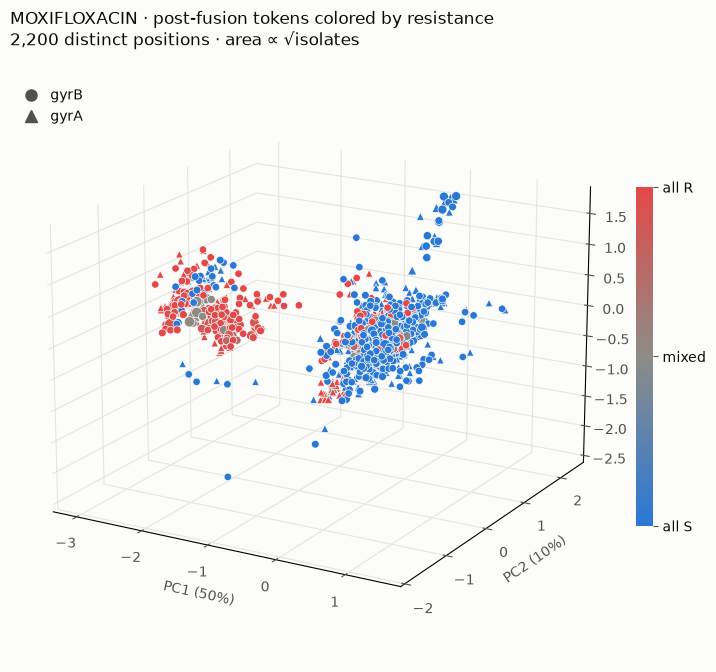

In [23]:
pheno = aggregate_phenotype(tokens_df, "post_centered")

# What §7's 95% clip would have cost here, measured rather than assumed:
box95 = view_box(tokens_df[tokens_df.stage == "post_centered"], 95)
out = np.zeros(len(pheno), bool)
for c, (lo, hi) in zip(("pc1", "pc2", "pc3"), box95):
    out |= ~pheno[c].between(lo, hi).values
print(f"a 95% clip would hide {int(pheno.n[out].sum()):,} of "
      f"{int(pheno.n.sum()):,} tokens ({pheno.n[out].sum() / pheno.n.sum():.1%}) "
      f"but {int(pheno.n_R[out].sum()):,} of {int(pheno.n_R.sum()):,} RESISTANT "
      f"ones ({pheno.n_R[out].sum() / pheno.n_R.sum():.1%})")

fig = plt.figure(figsize=(9.5, 8))
ax = fig.add_subplot(projection="3d")
drawn = plot_phenotype(pheno, ax, clip_box=None, scale=0.9)
_style(ax, "post_centered", pcas["post_centered"])
ax.legend(handles=[plt.Line2D([], [], ls="", marker=LOCUS_MARKER[l], ms=8,
                              color=MUTED, label=l) for l in LOCI],
          loc="upper left", bbox_to_anchor=(0.0, 0.95), labelcolor=INK,
          handletextpad=0.4, borderpad=0)
cb = fig.colorbar(plt.cm.ScalarMappable(norm=RS_NORM, cmap=RS_CMAP), ax=ax,
                  shrink=0.55, pad=0.02, ticks=[0, 0.5, 1])
cb.ax.set_yticklabels(["all S", "mixed", "all R"], color=INK)
cb.outline.set_visible(False)
ax.set_title(f"{cfg['drug']} · post-fusion tokens colored by resistance\n"
             f"{len(drawn):,} distinct positions · area ∝ √isolates",
             color=INK, loc="left", pad=0)
plt.savefig(OUT_DIR / f"tokens_post_phenotype_{cfg['drug']}.png", dpi=160,
            bbox_inches="tight")
plt.show()

### One point per isolate

The cloud above is one point per *token*, which is eight points per isolate and
not the object the label attaches to. This is the isolate-level view: the eight
post-fusion tokens concatenated into a single 1,024-d vector, PCA'd to 3D, one
marker per distinct genotype. No centering trick is needed here — the block
identities are constant across isolates, so PCA's own centering removes them.

This figure is **unclipped**. Everywhere else a 95% view box keeps heavy tails
from setting the scale, but here there are only a few hundred markers, so nothing
is lost to overplotting — and percentile clipping preferentially drops the *rare*
genotypes, which under an 8:1 class imbalance are disproportionately the resistant
ones. Hiding them would answer the question by throwing away the evidence.

In [24]:
iso_vec = post.reshape(n_iso, -1)                       # (n_iso, n_tok * d_model)
pca_iso = PCA(n_components=3, random_state=0).fit(iso_vec)
xyz_iso = pca_iso.transform(iso_vec)
ev = pca_iso.explained_variance_ratio_
print(f"isolate-level PCA on {iso_vec.shape[1]:,}-d post-fusion vectors: "
      f"PC1-3 = {ev.sum():.1%} ({' / '.join(f'{v:.1%}' for v in ev)})")

iso_df = pd.DataFrame({
    "stage": "isolate", "isolate": meta.isolate.values,
    "phenotype": meta.phenotype.values, "modality": "isolate",
    "locus": LOCI[0],
    "pc1": xyz_iso[:, 0], "pc2": xyz_iso[:, 1], "pc3": xyz_iso[:, 2]})
iso_pheno = aggregate_phenotype(iso_df, "isolate")
print(f"{len(iso_pheno):,} distinct genotypes among {n_iso:,} isolates")

isolate-level PCA on 1,024-d post-fusion vectors: PC1-3 = 81.8% (67.9% / 8.4% / 5.5%)
275 distinct genotypes among 2,868 isolates


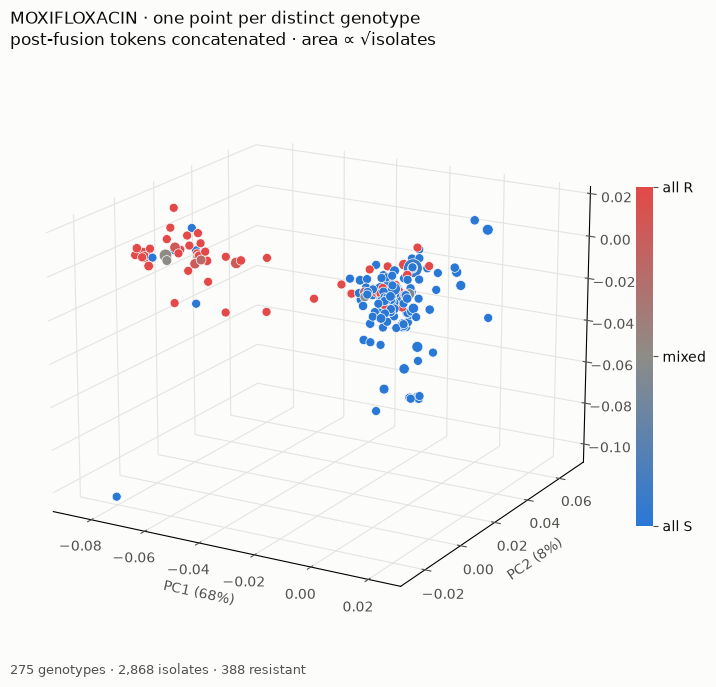

In [25]:
# NO clipping here. There are only a few hundred markers, so nothing is hidden by
# overplotting — and percentile clipping preferentially removes the RARE
# genotypes, which for an 8:1 imbalanced label are exactly the resistant ones.
fig = plt.figure(figsize=(9.5, 8))
ax = fig.add_subplot(projection="3d")
drawn = plot_phenotype(iso_pheno, ax, clip_box=None, scale=1.3, by_locus=False)
_style(ax, "isolate", pca_iso)
cb = fig.colorbar(plt.cm.ScalarMappable(norm=RS_NORM, cmap=RS_CMAP), ax=ax,
                  shrink=0.55, pad=0.02, ticks=[0, 0.5, 1])
cb.ax.set_yticklabels(["all S", "mixed", "all R"], color=INK)
cb.outline.set_visible(False)
ax.set_title(f"{cfg['drug']} · one point per distinct genotype\n"
             f"post-fusion tokens concatenated · area ∝ √isolates",
             color=INK, loc="left", pad=0)
ax.text2D(0.0, -0.02, f"{len(drawn):,} genotypes · {int(drawn.n.sum()):,} "
          f"isolates · {int(drawn.n_R.sum()):,} resistant",
          transform=ax.transAxes, color=MUTED, fontsize=9)
plt.savefig(OUT_DIR / f"isolates_post_phenotype_{cfg['drug']}.png", dpi=160,
            bbox_inches="tight")
plt.show()

### …and rotating, because 3D

Same isolate-level view, swept. A cluster that only exists at one camera angle is
a projection artefact.

In [26]:
def animate_phenotype(frames=72, elev=18, clip=None, figsize=(7.2, 6.3), dpi=90,
                      fps=12):
    fig = plt.figure(figsize=figsize, dpi=dpi)
    ax = fig.add_subplot(projection="3d")
    box = view_box(iso_df, clip) if clip else None
    plot_phenotype(iso_pheno, ax, clip_box=box, scale=1.0, by_locus=False)
    if box is not None:
        ax.set_xlim(*box[0]); ax.set_ylim(*box[1]); ax.set_zlim(*box[2])
    _style(ax, "isolate", pca_iso)
    cb = fig.colorbar(plt.cm.ScalarMappable(norm=RS_NORM, cmap=RS_CMAP), ax=ax,
                      shrink=0.5, pad=0.02, ticks=[0, 0.5, 1])
    cb.ax.set_yticklabels(["all S", "mixed", "all R"], color=INK, fontsize=8)
    cb.outline.set_visible(False)
    ax.set_title(f"{cfg['drug']} · genotypes by resistance, post-fusion",
                 color=INK, loc="left", pad=0)

    def frame(i):
        ax.view_init(elev=elev, azim=-60 + 360 * i / frames)
        return ()

    return FuncAnimation(fig, frame, frames=frames, interval=1000 / fps,
                         blit=False), fig


anim, fig = animate_phenotype()
pheno_gif = OUT_DIR / f"rotate_phenotype_{cfg['drug']}.gif"
anim.save(pheno_gif, writer=PillowWriter(fps=FPS))
plt.close(fig)
print(f"{pheno_gif}  ({pheno_gif.stat().st_size / 1e6:.1f} MB)")

/home/jacksonmicha_umass_edu/abr_workspace/biophysical-fusion/results/figures/token_pca/rotate_phenotype_MOXIFLOXACIN.gif  (2.7 MB)


In [27]:
HTML(f'<img src="../results/figures/token_pca/{pheno_gif.name}" '
     f'style="max-width:100%">')

### The transit, recolored

§7's fusion transit again — same shared basis, same endpoint-pair dedupe, same
straight-line paths — but colored by resistant fraction instead of modality. This
is the version that shows whether fusion *earns* its rearrangement, and it does:
at 0% the resistant and susceptible tokens are interleaved in one blob, and by
100% they have parted into two groups. The separation the phenotype figures above
show at rest is *produced here*, by the transformer, not inherited from the
encoders.

Two deliberate differences from §7's version. Locus is **not** encoded by marker
shape here: one scatter artist means the whole cloud can be depth-ordered by
resistant fraction, so the 8:1 minority is drawn last and never buried under
susceptible markers. And it is unclipped, for the reason measured above — §7's
transit hid 1,100 of 3,104 resistant tokens. The axes are wider as a result and
the core is denser; that is what the data looks like.

In [28]:
def animate_transit_phenotype(frames=72, elev=18, azim=-60, clip=None,
                              figsize=(7.2, 6.3), dpi=90, fps=12, decimals=4):
    is_R = (meta.phenotype.values == "resistant").astype(float)
    starts, ends, counts, fracs = [], [], [], []
    for i in range(len(model.block_keys)):
        key = np.round(np.hstack([START[:, i], END[:, i]]), decimals)
        uniq, inv, count = np.unique(key, axis=0, return_inverse=True,
                                     return_counts=True)
        starts.append(uniq[:, :3])
        ends.append(uniq[:, 3:])
        counts.append(count)
        fracs.append(np.bincount(inv, weights=is_R, minlength=len(uniq)) / count)
    a, b = np.vstack(starts), np.vstack(ends)
    n, frac = np.concatenate(counts), np.concatenate(fracs)

    stack = np.vstack([a, b])
    n_R = n * frac
    if clip is None:
        # the whole path of every token stays in frame; limits are still fixed
        # across frames, they are just the full bounding box
        box = [(stack[:, k].min(), stack[:, k].max()) for k in range(3)]
        inside = np.ones(len(a), bool)
        print(f"drawn: all {int(n.sum()):,} tokens "
              f"({int(n_R.sum()):,} resistant) — no clipping")
    else:
        lo, hi = (100 - clip) / 2, 100 - (100 - clip) / 2
        box = [tuple(np.percentile(stack[:, k], [lo, hi])) for k in range(3)]
        inside = np.ones(len(a), bool)
        for k, (klo, khi) in enumerate(box):    # both endpoints in view => the
            inside &= (a[:, k] >= klo) & (a[:, k] <= khi)  # whole path is too
            inside &= (b[:, k] >= klo) & (b[:, k] <= khi)
        print(f"drawn  : {int(n[inside].sum()):,} tokens "
              f"({int(n_R[inside].sum()):,} resistant)")
        print(f"hidden : {int(n[~inside].sum()):,} tokens "
              f"({int(n_R[~inside].sum()):,} resistant) outside the "
              f"central {clip}% view")
    a, b, n, frac = a[inside], b[inside], n[inside], frac[inside]

    order = np.argsort(frac)          # resistant drawn last, i.e. on top
    a, b, n, frac = a[order], b[order], n[order], frac[order]

    fig = plt.figure(figsize=figsize, dpi=dpi)
    ax = fig.add_subplot(projection="3d")
    sc = ax.scatter(a[:, 0], a[:, 1], a[:, 2], s=marker_size(n, n.max()) * 0.75,
                    c=frac, cmap=RS_CMAP, norm=RS_NORM, linewidths=0.5,
                    edgecolors=SURFACE, depthshade=False)
    ax.set_xlim(*box[0]); ax.set_ylim(*box[1]); ax.set_zlim(*box[2])
    ax.view_init(elev=elev, azim=azim)
    _style(ax, "transit", pca_transit)
    cb = fig.colorbar(plt.cm.ScalarMappable(norm=RS_NORM, cmap=RS_CMAP), ax=ax,
                      shrink=0.5, pad=0.11, ticks=[0, 0.5, 1])
    cb.ax.set_yticklabels(["all S", "mixed", "all R"], color=INK, fontsize=8)
    cb.outline.set_visible(False)
    ax.set_title(f"{cfg['drug']} · pre- to post-fusion, colored by resistance",
                 color=INK, loc="left", pad=0)
    caption = ax.text2D(0.0, -0.02, "", transform=ax.transAxes, color=MUTED,
                        fontsize=9)

    def frame(i):
        t = 0.5 - 0.5 * np.cos(2 * np.pi * i / frames)      # 0 -> 1 -> 0, eased
        p = (1 - t) * a + t * b
        sc._offsets3d = (p[:, 0], p[:, 1], p[:, 2])
        caption.set_text(f"through the fusion transformer: {t:.0%}")
        return ()

    return FuncAnimation(fig, frame, frames=frames, interval=1000 / fps,
                         blit=False), fig


anim, fig = animate_transit_phenotype()
transit_pheno_gif = OUT_DIR / f"transit_phenotype_{cfg['drug']}.gif"
anim.save(transit_pheno_gif, writer=PillowWriter(fps=FPS))
plt.close(fig)
print(f"{transit_pheno_gif}  ({transit_pheno_gif.stat().st_size / 1e6:.1f} MB)")

drawn: all 22,944 tokens (3,104 resistant) — no clipping


/home/jacksonmicha_umass_edu/abr_workspace/biophysical-fusion/results/figures/token_pca/transit_phenotype_MOXIFLOXACIN.gif  (0.9 MB)


In [29]:
HTML(f'<img src="../results/figures/token_pca/{transit_pheno_gif.name}" '
     f'style="max-width:100%">')

### The number that settles it

Eyeballing a 3D cloud is not evidence. Because isolates with an identical genotype
get an identical representation, they must receive an identical prediction — so
the best a model on these blocks could *possibly* do is score each isolate by the
resistant fraction of its own genotype group. That is a **ceiling on AUC**, and it
is computed on the very quantity the plots show. Comparing it against the run's
reported AUC says whether the remaining gap is the representation or the model.

In [30]:
from sklearn.metrics import roc_auc_score

# group on the FULL 1,024-d post-fusion vector, not its 3-PC shadow: two distinct
# genotypes can collide in three components and would inflate the ceiling.
_, gid = np.unique(np.round(iso_vec, 5), axis=0, return_inverse=True)
truth = (meta.phenotype == "resistant").values
frac_R = np.bincount(gid, weights=truth) / np.bincount(gid)
score = frac_R[gid]                       # each isolate scored by its own group
sizes = np.bincount(gid)
pure = (frac_R == 0) | (frac_R == 1)

print(f"genotype groups       : {len(frac_R):,} for {len(truth):,} isolates")
print(f"pure (all-R or all-S) : {pure.sum():,} groups, {sizes[pure].sum():,} "
      f"isolates ({sizes[pure].sum() / len(truth):.1%})")
print(f"mixed groups          : {(~pure).sum():,} groups, "
      f"{sizes[~pure].sum():,} isolates")
print()
print(f"ceiling AUC on this cohort : {roc_auc_score(truth, score):.3f}")
print(f"run's reported CV AUC      : 0.849 +/- 0.031")
print(f"run's reported test AUC    : 0.792")
print()
print("The ceiling is fit and scored on the same 2,868 isolates, so it is an "
      "upper bound on\nwhat these inputs can express about this cohort — not a "
      "generalization estimate. The\nreported AUCs are held out; the gap between "
      "them is headroom, not error.")

genotype groups       : 275 for 2,868 isolates
pure (all-R or all-S) : 246 groups, 485 isolates (16.9%)
mixed groups          : 29 groups, 2,383 isolates

ceiling AUC on this cohort : 0.886
run's reported CV AUC      : 0.849 +/- 0.031
run's reported test AUC    : 0.792

The ceiling is fit and scored on the same 2,868 isolates, so it is an upper bound on
what these inputs can express about this cohort — not a generalization estimate. The
reported AUCs are held out; the gap between them is headroom, not error.


### What is left

* **Other drugs** — everything above is driven by `RUN` / `STEM`. Any `setfusion`
  checkpoint works; a drug with more loci just adds marker shapes (`LOCUS_MARKER`
  holds four) and, past four modalities, would need the palette re-validated.
* **The attention read-out** — this notebook stops at the fusion output. The
  model's actual decision comes from the per-drug query attending over these
  tokens, and `forward(xs, return_attn=True)` returns that `(B, n_drugs,
  n_blocks)` map. Which locus each drug reads is a different, equally checkable
  question.